## Overview

This notebook implements an **LSTM-GARCH** model for one-day-ahead Bitcoin realized variance forecasting. The model operates in two sequential stages: an LSTM classifies the volatility regime, and a regime-conditioned GARCH model produces the variance forecast.

> **Note:** This architecture was ultimately abandoned. Fitting separate GARCH models on regime-stratified subpopulations breaks the temporal dependencies in the returns series — observations are no longer contiguous in time, violating a core assumption of GARCH-type models.


### Method

The pipeline combines two components trained and evaluated in sequence.

**Stage 1 — LSTM Regime Classifier**

An LSTM network is trained to predict the next day's volatility regime (Low / High) from a 32-feature input set. To address class imbalance and improve sensitivity to regime transitions, each training observation is assigned a weight

$$w_t = (1 - \lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}} + \lambda \frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\} \mathbf{1}\{g_s \ne g_{s-1}\}}$$

where $\lambda = 0.5$ balances class imbalance correction against emphasis on switching observations. The LSTM is trained using a **weighted categorical cross-entropy loss**

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} w_t \sum_{k=1}^{K} y_{t,k} \log(\hat{y}_{t,k})$$

**Stage 2 — Regime-Conditioned GARCH**

Separate GARCH(p, q) models are fitted on the returns of each regime using a 365-day rolling window. The final variance forecast is a **soft blend** weighted by the LSTM's predicted regime probabilities

$$\hat{\sigma}^2_t = \hat{p}_0 \cdot \hat{\sigma}^2_{\text{Low}} + \hat{p}_1 \cdot \hat{\sigma}^2_{\text{High}}$$

### Data & Features

- **Source:** `df_with_2regimes.csv` (from 2017-07-13)
- **Target:** next day's `log_realized_variance` (t+1)
- **Features (32):** log return, log volume, Google Trends, on-chain blockchain signals, cross-ass

In [1]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import os


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [3]:
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
df.head()
df.tail()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,p_sigma,p_r,p_d,regime,regime_id,log_realized_variance,rv_lag1,rv_lag2,rv_lag3,rv_rolling_mean_30
3120,2026-01-27,0.009776,0.000485,0.022018,-0.061538,-0.104979,-0.046198,0.021370,-0.235868,8.775873,...,0.866667,0.700000,0.583333,High,1.0,-7.631798,-7.940211,-8.366620,-10.489060,-8.413804
3121,2026-01-28,0.000510,0.000319,0.017847,-0.065574,-0.075153,0.240570,0.021306,0.359595,8.800436,...,0.533333,0.533333,0.500000,High,1.0,-8.051862,-7.631798,-7.940211,-8.366620,-8.431558
3122,2026-01-29,-0.053552,0.001190,0.034490,0.333333,0.243422,-0.024924,0.071430,0.118684,9.606559,...,0.966667,0.033333,0.966667,High,1.0,-6.734192,-8.051862,-7.631798,-7.940211,-8.370003
3123,2026-01-30,-0.004770,0.000855,0.029246,0.171053,-0.118552,0.068726,0.107636,0.416170,9.631273,...,0.933333,0.300000,0.816667,High,1.0,-7.064056,-6.734192,-8.051862,-7.631798,-8.314689
3124,2026-01-31,-0.067155,0.000998,0.031598,0.123596,0.062615,-0.051867,-0.096210,-0.546907,9.606164,...,0.933333,0.033333,0.950000,High,1.0,-6.909322,-7.064056,-6.734192,-8.051862,-8.224822


In [4]:
x_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg", 
    "rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]



print(len(x_features))

32


In [5]:
n = len(df)

train_size = int(n * 0.60)  # 60/25/15 split
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

# split eval into A and B
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

train_df = df.iloc[train_start_idx:train_end_idx].copy()
evalA_df = df.iloc[evalA_start_idx:evalA_end_idx].copy()
evalB_df = df.iloc[evalB_start_idx:evalB_end_idx].copy()
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set:  {len(train_df)} rows")
print(f"Eval A set: {len(evalA_df)} rows")
print(f"Eval B set: {len(evalB_df)} rows")
print(f"Test set:   {len(test_df)} rows")

Train set:  1875 rows
Eval A set: 390 rows
Eval B set: 391 rows
Test set:   469 rows


In [6]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

## Weighted LSTM Objective

Each observation is assigned a weight

$$
w_t = (1-\lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}}
+
\lambda
\frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}
{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}\mathbf{1}\{g_s \ne g_{s-1}\}}
$$

where

- $T$ is the number of observations  
- $g_t$ is the regime label at time $t$  
- $\mathbf{1}\{\cdot\}$ is the indicator function  
- $\lambda \in [0,1]$ controls the emphasis on regime switching observations.

The LSTM is trained using a **weighted categorical cross-entropy loss**

$$
\mathcal{L} =
-\frac{1}{T}
\sum_{t=1}^{T}
w_t
\sum_{k=1}^{K}
y_{t,k}\log(\hat{y}_{t,k})
$$

where

- $K$ = number of regimes  
- $y_{t,k}$ = true indicator of regime $k$ at time $t$  
- $\hat{y}_{t,k}$ = predicted probability from the LSTM softmax layer  
- $w_t$ = observation weight.

In [7]:
def compute_weights(regimes, lam=0.5, eps=1e-12):
    regimes = np.asarray(regimes).astype(int)
    T = len(regimes)

    switch_flag = np.zeros(T, dtype=int)
    switch_flag[1:] = (regimes[1:] != regimes[:-1]).astype(int)

    unique_regimes = np.unique(regimes)

    class_count = {g: np.sum(regimes == g) for g in unique_regimes}
    switch_count = {
        g: np.sum((regimes == g) & (switch_flag == 1))
        for g in unique_regimes
    }
    total_switches = np.sum(switch_flag)

    weights = np.zeros(T, dtype=float)

    for t in range(T):
        g = regimes[t]

        imbalance_term = T / (class_count[g] + eps)

        if total_switches > 0 and switch_count[g] > 0:
            switch_term = total_switches / (switch_count[g] + eps)
        else:
            switch_term = 0.0 

        weights[t] = (1 - lam) * imbalance_term + lam * switch_term 

    # normalize weights for stability
    weights = weights / np.mean(weights)

    return weights, switch_flag

In [8]:
# use this for evaluation and testing
def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback - 1, scale_window - 1)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

In [9]:
def create_rolling_scaled_sequences_range_weights(
    df, feature_cols, target_col, lookback, scale_window,
    start_idx, end_idx, weights_full, date_col=None
):
    X, y, dates, target_idx, w = [], [], [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]
        target = df[target_col].iloc[t + 1]

        weight = weights_full[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        if pd.isna(weight):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)
        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)
        w.append(weight)
        target_idx.append(t + 1)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates, np.array(w), np.array(target_idx)


def scale_rolling(df_hist, feature_cols, lookback, scale_window=730):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler


In [10]:
def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

In [12]:
def fit_garch_safe(returns, p=1, q=1, dist="t", vol_model="GARCH", min_obs=100):
    returns = returns.dropna().astype(float)

    if len(returns) < min_obs:
        return None

    try:
        vol_model = vol_model.upper()

        kwargs = dict(
            y=returns * 100.0,
            mean="constant",
            vol=vol_model,
            p=p,
            q=q,
            dist=dist
        )

        am = arch_model(**kwargs)
        res = am.fit(disp="off")
        return res

    except Exception:
        return None


def one_step_var_forecast(fitted_vol_model):
    if fitted_vol_model is None:
        return np.nan

    try:
        fcast = fitted_vol_model.forecast(horizon=1, reindex=False)
        var_100 = fcast.variance.values[-1, 0]
        return var_100 / (100.0 ** 2)
    except Exception:
        return np.nan

In [13]:
def rolling_lstm_garch_soft_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    return_col="log_return",
    realized_var_col="log_realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=1,
    garch_q=1,
    vol_model="GARCH",
    garch_dist="t",
    rolling_window=730,
    min_obs=100,
    eps=1e-12
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training window uses data up to time t
        window_df = df.iloc[max(0, t - rolling_window + 1): t + 1].copy()

        low_returns = window_df.loc[window_df[regime_col] == 0, return_col].dropna()
        high_returns = window_df.loc[window_df[regime_col] == 1, return_col].dropna()

        # print(low_returns.shape, high_returns.shape)

        p0 = current_row.get("prob0_for_next_day", np.nan)
        p1 = current_row.get("prob1_for_next_day", np.nan)
        pred_regime = current_row.get("regime_for_next_day", np.nan)

        if (
            len(low_returns) < min_obs
            or len(high_returns) < min_obs
            or pd.isna(p0)
            or pd.isna(p1)
        ):
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "true_regime": next_row[regime_col],
                "pred_regime": pred_regime,
                "pred_prob_0": p0,
                "pred_prob_1": p1,
                "var_low": np.nan,
                "var_high": np.nan,
                "var_soft": np.nan,
                "log_var_soft": np.nan
            })
            continue

        garch_low = fit_garch_safe(
            low_returns,
            p=garch_p,
            q=garch_q,
            vol_model=vol_model,
            dist=garch_dist,
            min_obs=min_obs
        )

        garch_high = fit_garch_safe(
            high_returns,
            p=garch_p,
            q=garch_q,
            vol_model=vol_model,
            dist=garch_dist, 
            min_obs=min_obs
        )

        var_low = one_step_var_forecast(garch_low)
        var_high = one_step_var_forecast(garch_high)

        if np.isfinite(var_low) and np.isfinite(var_high):
            var_soft = p0 * var_low + p1 * var_high
            #log_var_soft = np.log(var_soft + eps)
        else:
            var_soft = np.nan
            #log_var_soft = np.nan

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_var": next_row[realized_var_col],
            "true_regime": next_row[regime_col],
            "pred_regime": pred_regime,
            "pred_prob_0": p0,
            "pred_prob_1": p1,
            "var_low": var_low,
            "var_high": var_high,
            "var_soft": var_soft,
            #"log_var_soft": log_var_soft
        })

    return pd.DataFrame(results)

#### metrics

In [14]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


In [15]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
from itertools import product 
from arch import arch_model
import tensorflow as tf
import gc

In [16]:
from itertools import product

lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.1, 0.2],
    "batch_size": [32, 64]
}

lstm_param_grid = []
for lb, units, drop, bs in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"]
):
    lstm_param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs
    })

# --------------------------------
# GARCH grid
# --------------------------------
garch_grid = {
    "vol_model": ["GARCH"],
    "p": [1, 2],
    "q": [1, 2],
    "dist": ["t"]
}

garch_param_grid = []
for vol_model, p, q, dist in product(
    garch_grid["vol_model"],
    garch_grid["p"],
    garch_grid["q"],
    garch_grid["dist"]
):
    garch_param_grid.append({
        "vol_model": vol_model,
        "p": p,
        "q": q,
        "dist": dist
    })

print(f"Total LSTM configs: {len(lstm_param_grid)}")
print(f"Total GARCH configs: {len(garch_param_grid)}")

Total LSTM configs: 36
Total GARCH configs: 4


In [20]:
fixed_garch_params = {
    "p": 1,
    "q": 1,
    "vol_model": "GARCH",
    "dist": "t"
}
stage2_window = 365
min_obs = 100

lstm_results = []

for i, params in enumerate(lstm_param_grid, 1):
    lb = params["lookback"]
    units = params["units"]
    drop = params["dropout"]
    bs = params["batch_size"]

    print(f"\n[{i}/{len(lstm_param_grid)}] Testing LSTM: {params}")

    try:
        K.clear_session()
        tf.keras.backend.clear_session()
        gc.collect()

        # -----------------------------
        # 1) Train LSTM on TRAIN only
        # -----------------------------
        train_weights_full, train_switch_flags = compute_weights(
            train_df["regime_id"].values, lam=0.5
        )

        X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
            create_rolling_scaled_sequences_range_weights(
                df=train_df,
                feature_cols=x_features,
                target_col="regime_id",
                lookback=lb,
                scale_window=365,
                start_idx=0,
                end_idx=len(train_df),
                weights_full=train_weights_full,
                date_col="date"
            )
        )

        w_train = w_train.astype(np.float32)

        # -----------------------------------
        # 2) Validate LSTM on Eval A only
        # -----------------------------------
        X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
            df=df,
            feature_cols=x_features,
            target_col="regime_id",
            lookback=lb,
            scale_window=365,
            start_idx=evalA_start_idx,
            end_idx=evalA_end_idx,
            date_col="date"
        )

        if len(X_train_lstm) == 0 or len(X_evalA_lstm) == 0:
            print("Skipping: no sequences produced.")
            lstm_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no sequences produced"
            })
            continue

        y_train_cat = to_categorical(y_train_regime, num_classes=2)
        y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

        model = build_lstm_model(
            lookback=lb,
            n_features=len(x_features),
            n_regimes=2,
            units=units,
            dropout=drop,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train_lstm,
            y_train_cat,
            sample_weight=w_train,
            validation_data=(X_evalA_lstm, y_evalA_cat),
            epochs=100,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )

        # ---------------------------------------------------------
        # 3) Generate regime probabilities on Eval A + Eval B
        #    starting early enough for stage-2 rolling history
        # ---------------------------------------------------------
        regime_start_idx = max(0, evalA_start_idx - stage2_window)

        evalAB_regime_roll = rolling_regime_forecast(
            df_full=df,
            lstm_model=model,
            feature_cols=x_features,
            lookback=lb,
            start_idx=regime_start_idx,
            end_idx=evalB_end_idx,
            scale_window=365,
            date_col="date",
            target_col="regime_id"
        )

        # ------------------------------------------------
        # 4) Tune/evaluate stage-2 garch on Eval B only
        # ------------------------------------------------
        evalB_stage2 = rolling_lstm_garch_soft_eval(
                df_full=df,
                regime_forecast_df=evalAB_regime_roll,
                start_idx=evalB_start_idx,
                end_idx=evalB_end_idx,
                realized_var_col="log_realized_variance",
                date_col="date",
                rolling_window=stage2_window,
                garch_p=fixed_garch_params["p"],
                garch_q=fixed_garch_params["q"],
                vol_model=fixed_garch_params["vol_model"],
                garch_dist=fixed_garch_params["dist"],
                min_obs=min_obs
            )

        evalB_rmse = rmse(
                evalB_stage2["actual_var"],
                evalB_stage2["var_soft"]
            )

        evalB_qlike = qlike(
                np.exp(evalB_stage2["actual_var"]),
                np.exp(evalB_stage2["var_soft"])
            )

        n_evalB_forecasts = evalB_stage2["var_soft"].notna().sum()

        lstm_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        print(f"Error for params {params}: {e}")
        lstm_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })
lstm_results_df = pd.DataFrame(lstm_results).sort_values("evalB_qlike")



[1/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32}

[2/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 64}

[3/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 32}

[4/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 64}

[5/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 32}

[6/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.2, 'batch_size': 64}

[7/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 32}

[8/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.0, 'batch_size': 64}

[9/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 32}

[10/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.1, 'batch_size': 64}

[11/36] Testing LSTM: {'lookback': 20, 'units': 64, 'dropout': 0.2, 'batch_size': 32}

[12/36] Testing LSTM: {'lookback': 20, 'units': 64,

In [21]:
lstm_results

[{'lookback': 20,
  'units': 32,
  'dropout': 0.0,
  'batch_size': 32,
  'evalB_rmse': 7.843017245815732,
  'evalB_qlike': 6.77625013196823,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.0,
  'batch_size': 64,
  'evalB_rmse': 7.843018426973122,
  'evalB_qlike': 6.776254670429281,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.1,
  'batch_size': 32,
  'evalB_rmse': 7.8430177520461815,
  'evalB_qlike': 6.7762517372516555,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.1,
  'batch_size': 64,
  'evalB_rmse': 7.843041855501633,
  'evalB_qlike': 6.776273655535906,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.2,
  'batch_size': 32,
  'evalB_rmse': 7.842974035029781,
  'evalB_qlike': 6.77620881642951,
  'n_evalB_forecasts': 391},
 {'lookback': 20,
  'units': 32,
  'dropout': 0.2,
  'batch_size': 64,
  'evalB_rmse': 7.842958200409983,
  'evalB_qlike': 6.776191787219164,
  '

In [22]:
print(lstm_results_df.head())
best_lstm_params = lstm_results_df.iloc[0].to_dict()
print(best_lstm_params)

    lookback  units  dropout  batch_size  evalB_rmse  evalB_qlike  \
5         20     32      0.2          64    7.842958     6.776192   
7         20     64      0.0          64    7.842966     6.776200   
4         20     32      0.2          32    7.842974     6.776209   
10        20     64      0.2          32    7.842980     6.776215   
17        30     32      0.2          64    7.842991     6.776222   

    n_evalB_forecasts  
5                 391  
7                 391  
4                 391  
10                391  
17                391  
{'lookback': 20.0, 'units': 32.0, 'dropout': 0.2, 'batch_size': 64.0, 'evalB_rmse': 7.842958200409983, 'evalB_qlike': 6.776191787219164, 'n_evalB_forecasts': 391.0}


In [23]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])

train_weights_full, train_switch_flags = compute_weights(
    train_df["regime_id"].values, lam=0.5
)

# 1) Train LSTM on TRAIN only
X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_df,
        feature_cols=x_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_df),
        weights_full=train_weights_full,
        date_col="date"
    )
)

w_train = w_train.astype(np.float32)
y_train_cat = to_categorical(y_train_regime, num_classes=2)

# 2) Validate / early stop on EVAL A only
X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
    df=df,
    feature_cols=x_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=365,
    start_idx=evalA_start_idx,
    end_idx=evalA_end_idx,
    date_col="date"
)

y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

best_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(x_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_lstm_model.fit(
    X_train_lstm,
    y_train_cat,
    sample_weight=w_train,
    validation_data=(X_evalA_lstm, y_evalA_cat),
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop],
    verbose=0
)

# 3) Generate fixed regime probabilities for garch tuning on Eval B
# start early enough so stage-2 has rolling history
stage2_window = 365
regime_start_idx = max(0, evalB_start_idx - stage2_window)

eval_regime_fixed = rolling_regime_forecast(
    df_full=df,
    lstm_model=best_lstm_model,
    feature_cols=x_features,
    lookback=best_lb,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

In [24]:
garch_results = []

for i, params in enumerate(garch_param_grid, 1):
    p = params["p"]
    q = params["q"]
    vol_model = params.get("vol_model", "GARCH")
    dist = params.get("dist", "t")

    print(f"\n[{i}/{len(garch_param_grid)}] Testing GARCH: {params}")

    try:
        evalB_garch = rolling_lstm_garch_soft_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            return_col="log_return",
            realized_var_col="log_realized_variance",
            regime_col="regime_id",
            date_col="date",
            garch_p=p,
            garch_q=q,
            vol_model=vol_model,
            garch_dist=dist,
            rolling_window=365,
            min_obs=100
        )

        # RMSE on log-variance scale
        evalB_rmse = rmse(
            evalB_garch["actual_var"],
            evalB_garch["var_soft"]
        )

        # QLIKE on variance scale
        evalB_qlike = qlike(
            np.exp(evalB_garch["actual_var"]),
            np.exp(evalB_garch["var_soft"])
        )

        n_evalB_forecasts = evalB_garch["var_soft"].notna().sum()

        garch_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        garch_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

garch_results_df = pd.DataFrame(garch_results).sort_values("evalB_qlike")
print(garch_results_df.head())


[1/4] Testing GARCH: {'vol_model': 'GARCH', 'p': 1, 'q': 1, 'dist': 't'}

[2/4] Testing GARCH: {'vol_model': 'GARCH', 'p': 1, 'q': 2, 'dist': 't'}

[3/4] Testing GARCH: {'vol_model': 'GARCH', 'p': 2, 'q': 1, 'dist': 't'}

[4/4] Testing GARCH: {'vol_model': 'GARCH', 'p': 2, 'q': 2, 'dist': 't'}
  vol_model  p  q dist  evalB_rmse  evalB_qlike  n_evalB_forecasts
1     GARCH  1  2    t    7.843020     6.776253                391
3     GARCH  2  2    t    7.843022     6.776255                391
0     GARCH  1  1    t    7.843039     6.776271                391
2     GARCH  2  1    t    7.843044     6.776276                391


In [25]:
best_garch_params = garch_results_df.iloc[0].to_dict()
print(best_garch_params)

{'vol_model': 'GARCH', 'p': 1, 'q': 2, 'dist': 't', 'evalB_rmse': 7.843020448207967, 'evalB_qlike': 6.776253122222299, 'n_evalB_forecasts': 391}


In [26]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])

# =====================================================
# FINAL LSTM TRAINING FOR OUT-OF-SAMPLE TEST
# Train on all data before test = TRAIN + EVAL
# =====================================================
train_eval_df = df.iloc[:test_start_idx].copy()

train_eval_weights_full, train_eval_switch_flags = compute_weights(
    train_eval_df["regime_id"].values, lam=0.5
)

# 1) Train final LSTM on TRAIN + EVAL
X_train_eval_lstm, y_train_eval_regime, train_eval_dates, w_train_eval, train_eval_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_eval_df,
        feature_cols=x_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_eval_df),
        weights_full=train_eval_weights_full,
        date_col="date"
    )
)

w_train_eval = w_train_eval.astype(np.float32)
y_train_eval_cat = to_categorical(y_train_eval_regime, num_classes=2)

final_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(x_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop_final = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

final_lstm_model.fit(
    X_train_eval_lstm,
    y_train_eval_cat,
    sample_weight=w_train_eval,
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop_final],
    verbose=0
)

# 2) Generate regime probabilities for TEST
stage2_window = 365
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_lstm_model,
    feature_cols=x_features,
    lookback=best_lb,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

In [31]:
test_regime_start_idx = max(0, test_start_idx - 365)

test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_lstm_model,
    feature_cols=x_features,
    lookback=best_lb,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

test_garch = rolling_lstm_garch_soft_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    return_col="log_return",
    realized_var_col="log_realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=int(best_garch_params["p"]),
    garch_q=int(best_garch_params["q"]),
    vol_model=best_garch_params["vol_model"],
    garch_dist=best_garch_params["dist"],
    rolling_window=365,
    min_obs=100
)


# output from garch is variance 

# RMSE on log-variance scale
test_rmse = rmse(
    test_garch["actual_var"],
    np.log(test_garch["var_soft"])
)

# RSME on variance scale 
test_rmse_var = rmse(
    np.exp(test_garch["actual_var"]),
    test_garch["var_soft"]
)

# QLIKE on variance scale
test_qlike = qlike(
    np.exp(test_garch["actual_var"]),
    test_garch["var_soft"]
)

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_garch["var_soft"].notna().sum())

Final Test RMSE : 1.162560909117778
Final Test RMSE (var scale): 0.0006933923050572076
Final Test QLIKE: 0.7309437412319761
Number of test forecasts: 469


In [32]:
test_garch.head(10)

,date,forecast_origin_date,actual_var,true_regime,pred_regime,pred_prob_0,pred_prob_1,var_low,var_high,var_soft
0,2024-10-20,2024-10-19,-9.314845,0.0,0.0,9.592611e-01,0.040739,0.000177,0.000874,0.000205
1,2024-10-21,2024-10-20,-7.873473,0.0,1.0,3.939554e-02,0.960604,0.000164,0.000873,0.000845
2,2024-10-22,2024-10-21,-8.046507,0.0,1.0,8.214453e-09,1.000000,0.000249,0.000859,0.000859
3,2024-10-23,2024-10-22,-8.161787,0.0,1.0,1.046847e-09,1.000000,0.000159,0.000795,0.000795
4,2024-10-24,2024-10-23,-7.997675,0.0,1.0,9.439007e-10,1.000000,0.000231,0.000803,0.000803
5,2024-10-25,2024-10-24,-7.679053,1.0,1.0,7.223829e-10,1.000000,0.000211,0.000814,0.000814
6,2024-10-26,2024-10-25,-9.827359,0.0,1.0,2.188981e-05,0.999978,0.000211,0.000829,0.000829
7,2024-10-27,2024-10-26,-9.277379,0.0,1.0,6.455830e-02,0.935442,0.000208,0.000839,0.000798
8,2024-10-28,2024-10-27,-8.498660,0.0,1.0,9.991895e-07,0.999999,0.000207,0.000839,0.000839
9,2024-10-29,2024-10-28,-7.399876,1.0,1.0,1.658576e-09,1.000000,0.000289,0.000839,0.000839


In [33]:
test_garch.head()

,date,forecast_origin_date,actual_var,true_regime,pred_regime,pred_prob_0,pred_prob_1,var_low,var_high,var_soft
0,2024-10-20,2024-10-19,-9.314845,0.0,0.0,9.592611e-01,0.040739,0.000177,0.000874,0.000205
1,2024-10-21,2024-10-20,-7.873473,0.0,1.0,3.939554e-02,0.960604,0.000164,0.000873,0.000845
2,2024-10-22,2024-10-21,-8.046507,0.0,1.0,8.214453e-09,1.000000,0.000249,0.000859,0.000859
3,2024-10-23,2024-10-22,-8.161787,0.0,1.0,1.046847e-09,1.000000,0.000159,0.000795,0.000795
4,2024-10-24,2024-10-23,-7.997675,0.0,1.0,9.439007e-10,1.000000,0.000231,0.000803,0.000803


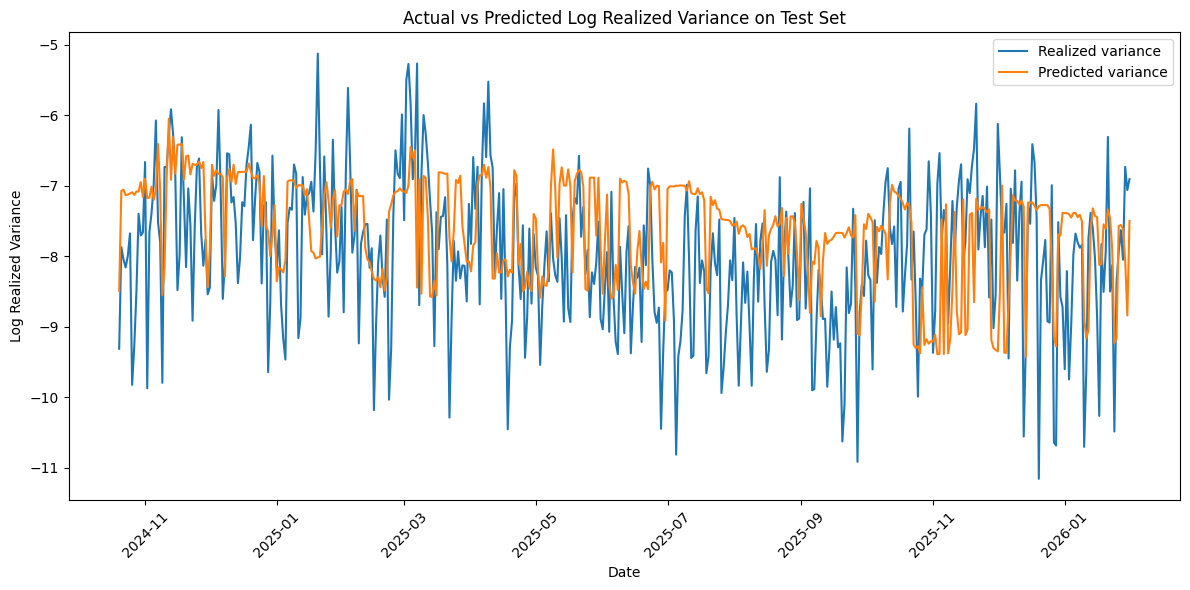

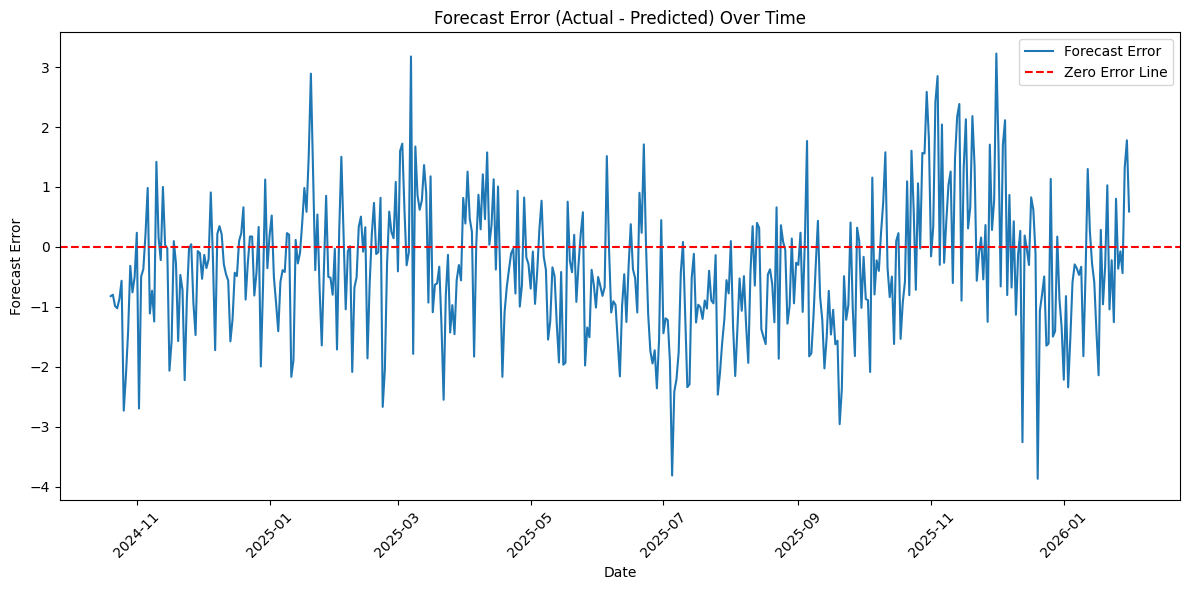

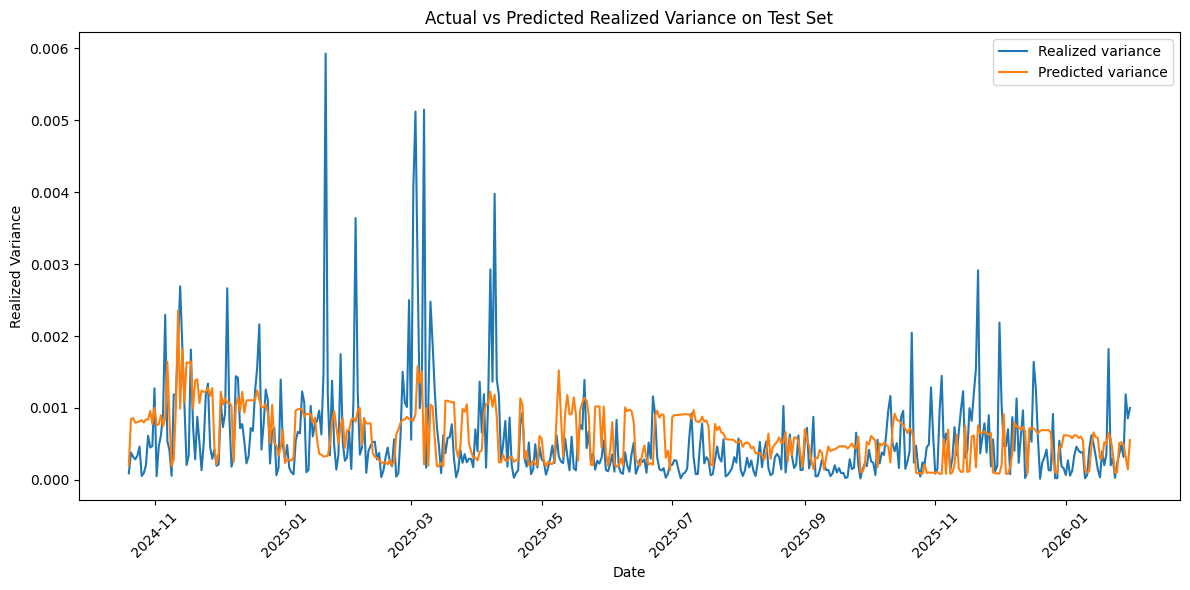

In [34]:
# plot actual vs predicted log variance on test set
import matplotlib.pyplot as plt
test_garch['date'] = pd.to_datetime(test_garch['date'])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["actual_var"], label="Realized variance")
plt.plot(test_garch["date"], np.log(test_garch["var_soft"]), label="Predicted variance")
plt.title("Actual vs Predicted Log Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Log Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_garch['date'] = pd.to_datetime(test_garch['date'])
test_garch['error'] = test_garch["actual_var"] - np.log(test_garch["var_soft"])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], test_garch["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot actual vs predicted variance on test set
test_garch['date'] = pd.to_datetime(test_garch['date'])
plt.figure(figsize=(12,6))
plt.plot(test_garch["date"], np.exp(test_garch["actual_var"]), label="Realized variance")
plt.plot(test_garch["date"], test_garch["var_soft"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
# export result to csv
#test_garch.to_csv("results/lstm_garch4_test_results.csv", index=False)

In [ ]:
# predicted regime vs actual regime confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(test_garch["true_regime"], test_garch["pred_regime"])
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(test_garch["true_regime"], test_garch["pred_regime"]))
